# TensorFlow Neural Architecture Codesign (NAC) with Resource Utilization and Latency Estimation for ML on FPGA (rule4ml) Tutorial

In this tutorial, you will be able to run a search to optimize a model with respect to performance and hardware metrics. This consists of 3 stages: global search, local search, and model synthesis.

### Setup

In [1]:
# Create an env and install requirements

# !python -m venv nac_rule4ml_env

In [2]:
# %pip install -r requirements.txt

## Global Search
In the global search, the user provides a dataset, model, and search space (defaults are provided). It is recommended to create a search space in the same structure as defined below. Global search can then be ran with user defined metrics to optimize for, i.e. accuracy, BOPs, average hardware utilization, clock cycles

### Dataset loading & Preprocessing (notebook)

In [3]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

def load_and_preprocess_data(resize_val=8, subset_size=None):
    """
    Loads the MNIST dataset, preprocesses it by resizing, normalizing, and flattening the images,
    and converts the labels to one-hot encoding. Optionally, a subset of the data can be used.
    
    Parameters:
        resize_val (int): The target height and width for resizing the images.
        subset_size (int or None): If specified, the number of samples to use from the training and validation sets.
    
    Returns:
        x_train, y_train, x_val, y_val: Preprocessed training and validation data.
    """
    # Load MNIST dataset
    (x_train_full, y_train_full), (x_val_full, y_val_full) = mnist.load_data()

    # Expand dims: from (num_samples, 28, 28) to (num_samples, 28, 28, 1)
    x_train_full = x_train_full[..., None]
    x_val_full = x_val_full[..., None]

    # Resize images
    x_train_full = tf.image.resize(x_train_full, [resize_val, resize_val]).numpy()
    x_val_full = tf.image.resize(x_val_full, [resize_val, resize_val]).numpy()

    # Normalize pixel values to [0, 1]
    x_train_full = x_train_full.astype("float32") / 255.0
    x_val_full = x_val_full.astype("float32") / 255.0

    # Flatten images: reshape (num_samples, resize_val, resize_val, 1) to (num_samples, resize_val*resize_val)
    squared_resize = resize_val ** 2
    x_train_full = x_train_full.reshape(-1, squared_resize)
    x_val_full = x_val_full.reshape(-1, squared_resize)

    # Convert labels to one-hot encoding (10 classes)
    num_classes = 10
    y_train_full = to_categorical(y_train_full, num_classes)
    y_val_full = to_categorical(y_val_full, num_classes)

    # Subset if specified
    if subset_size is not None:
        x_train = x_train_full[:subset_size]
        y_train = y_train_full[:subset_size]
        x_val = x_val_full[:subset_size]
        y_val = y_val_full[:subset_size]
    else:
        x_train, y_train, x_val, y_val = x_train_full, y_train_full, x_val_full, y_val_full

    print("x_train shape:", x_train.shape)
    return x_train, y_train, x_val, y_val

2025-08-06 10:50:42.396919: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


x_train shape: (60000, 64)


2025-08-06 10:50:46.103885: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


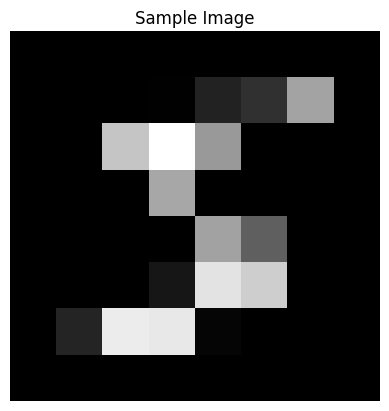

In [4]:
def visualize_sample(x_train, index=0, resize_val=8):
    """
    Visualizes a sample image from the training set.
    
    Parameters:
        x_train (np.array): The training data containing flattened images.
        index (int): The index of the image to visualize.
        resize_val (int): The height and width used in preprocessing.
    """
    # Reshape the flattened image back to its 2D form
    image = x_train[index].reshape(resize_val, resize_val)
    plt.imshow(image, cmap="gray")
    plt.title("Sample Image")
    plt.axis("off")
    plt.show()

x_train, y_train, x_val, y_val = load_and_preprocess_data(resize_val=8, subset_size=60000)
visualize_sample(x_train, index=0, resize_val=8)

### Run global search

In [ ]:
!python global_search_tf.py

2025-08-06 10:50:46.457166: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-06 10:50:48.168257: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
[I 2025-08-06 10:50:48,232] A new study created in memory with name: no-name-7eeb5036-fabb-4b4e-9e17-70ada8c76862
BOPs: 0
Trial  0  begins evaluation...
Test Accuracy: 0.0000
Test Accuracy: 0.2742
Validation Accuracy: 0.0000, Test Accuracy: 0.2742, Inference time: 0.4601, Validat

### Plotting Results

In [ ]:
!python plot_results.py --results_file global_search_results.txt --objectives "accuracy,BOPs,param_count,inference_time" --maximize "True,False,False,False"

# Define the objectives based on those chosen for the global search
# Pareto points selected if the point cannot be improved without worsening another

Traceback (most recent call last):
  File "/home/users/ddemler/dima_stuff/tutorialFastML/tutorial-nac-opt/plot_results.py", line 132, in <module>
    main()
  File "/home/users/ddemler/dima_stuff/tutorialFastML/tutorial-nac-opt/plot_results.py", line 125, in main
    df = parse_results(args.results_file, objective_names)
  File "/home/users/ddemler/dima_stuff/tutorialFastML/tutorial-nac-opt/plot_results.py", line 17, in parse_results
    with open(filepath, "r") as f:
FileNotFoundError: [Errno 2] No such file or directory: 'global_search_results.txt'


In [ ]:
from IPython.display import Image
Image("pareto_fronts.png")

FileNotFoundError: No such file or directory: 'pareto_fronts.png'

FileNotFoundError: No such file or directory: 'pareto_fronts.png'

<IPython.core.display.Image object>

### 3D Plot

In [ ]:
def pareto_front_indices_general(df, objectives, maximize_flags):
    """
    Returns indices of non-dominated (Pareto optimal) points for a set of objectives.
    
    Parameters:
        df (pd.DataFrame): DataFrame with objective columns.
        objectives (list of str): List of objective names to compare.
        maximize_flags (list of bool): List of booleans indicating if each objective should be maximized.
        
    Returns:
        list: Indices of non-dominated points.
    """
    # Create a list of transformed objective arrays. If an objective is to be maximized,
    # we flip its sign so that all objectives can be treated as minimization.
    f_list = []
    for obj, maximize in zip(objectives, maximize_flags):
        f_list.append(-df[obj] if maximize else df[obj])
    
    n = len(df)
    indices = []
    
    # Loop through each point in the df, get pareto front
    for i in range(n):
        current = [f.iloc[i] for f in f_list]
        dominated = False
        for j in range(n):
            if i == j:
                continue
            other = [f.iloc[j] for f in f_list]
            # Check if other dominates current:
            if all(o <= c for o, c in zip(other, current)) and any(o < c for o, c in zip(other, current)):
                dominated = True
                break
        if not dominated:
            indices.append(i)
    
    return indices

In [ ]:
import plotly.graph_objects as go

def plot_3d_with_heatmap(df, objectives_info):
    """
    Plots a 3D scatter plot using the first three objectives as axes
    and the fourth objective as a heat map (color).

    Parameters:
        df (pd.DataFrame): DataFrame containing the objective data.
        objectives_info (list of tuples): A list of four tuples (name, maximize),
            where the first three correspond to the x, y, and z dimensions,
            and the fourth is used for the color mapping.
    """
    if len(objectives_info) != 4:
        raise ValueError("Exactly 4 objectives must be provided.")
    
    # Unpack objective names and maximize flags.
    obj1, obj2, obj3, obj4 = [info[0] for info in objectives_info]
    max1, max2, max3, _ = [info[1] for info in objectives_info]
    
    # Use the generalized Pareto front function for the first three objectives.
    pareto_indices = pareto_front_indices_general(df, [obj1, obj2, obj3], [max1, max2, max3])
    pareto_points = df.iloc[pareto_indices]
    
    fig = go.Figure()
    
    # Trace for all trials, colored by the 4th objective.
    fig.add_trace(go.Scatter3d(
        x=df[obj1],
        y=df[obj2],
        z=df[obj3],
        mode="markers",
        marker=dict(
            size=5,
            color=df[obj4],
            colorscale="Viridis",
            opacity=0.6,
            colorbar=dict(title=obj4)
        ),
        name="All Trials"
    ))
    
    # Trace for Pareto front points.
    fig.add_trace(go.Scatter3d(
        x=pareto_points[obj1],
        y=pareto_points[obj2],
        z=pareto_points[obj3],
        mode="markers",
        marker=dict(
            size=8,
            color=pareto_points[obj4],
            colorscale="Viridis",
            symbol="diamond",
            colorbar=dict(title=obj4)
        ),
        name="Pareto Front (3D)"
    ))
    
    # Update layout with axis titles and overall title.
    fig.update_layout(
        title=f"3D Pareto Front: {obj1} vs {obj2} vs {obj3} with {obj4} as color",
        scene=dict(
            xaxis_title=obj1,
            yaxis_title=obj2,
            zaxis_title=obj3
        )
    )
    
    fig.show()

In [ ]:
from plot_results import parse_results

# Define the objective names in order of appearance based on global search
objective_names = ["accuracy", "BOPs", "param_count", "inference_time"]

# Parse
df = parse_results("global_search_results.txt", objective_names)
print("Parsed results:")
print(df)

objectives_info = [
    ("accuracy", True),    # maximize
    ("BOPs", False),   # minimize
    ("param_count", False),  # minimize
    ("inference_time", False)        # used as heat map (color)
]

FileNotFoundError: [Errno 2] No such file or directory: 'global_search_results.txt'

In [ ]:
plot_3d_with_heatmap(df, objectives_info)